#### **Этап 1. Подготовка данных**
Скачайте файл с набором данных событий информационной безопасности в формате JSON (events.json). Важно: можно сгенерировать данные самостоятельно или использовать предоставленные.  

#### **Этап 2. Анализ данных**
Загрузите данные из файла JSON в датафрейм с помощью Pandas и проанализируйте их. Вы должны изучить распределение событий информационной безопасности по их типам (по полю «signature»).

In [11]:
%pip install --upgrade pandas

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0
[notice] To update, run: C:\Users\Kovalev\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import json
import pandas as pd

In [ ]:
with open('events.json', 'r') as file:
    data = json.load(file)
    df = pd.DataFrame(data['events'])
df.head()

,timestamp,signature
0,2023-08-21T08:00:00,MALWARE-CNC Win.Trojan.Jadtre variant outbound...
1,2023-08-21T09:00:00,EXPLOIT Remote Windows Win32k elevation of pri...
2,2023-08-21T10:00:00,EXPLOIT Java JRE to Oracle WebLogic RCE
3,2023-08-21T11:00:00,NETBIOS DCERPC NCACN-IP-TCP interfaces BO
4,2023-08-21T12:00:00,MALWARE-CNC User-Agent known malicious connect...


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  100 non-null    datetime64[us]
 1   signature  100 non-null    str           
dtypes: datetime64[us](1), str(1)
memory usage: 1.7 KB


In [ ]:
df['signature'].unique()

<StringArray>
[   'MALWARE-CNC Win.Trojan.Jadtre variant outbound connection',
 'EXPLOIT Remote Windows Win32k elevation of privilege attempt',
                      'EXPLOIT Java JRE to Oracle WebLogic RCE',
                    'NETBIOS DCERPC NCACN-IP-TCP interfaces BO',
         'MALWARE-CNC User-Agent known malicious connecting IP',
   'INDICATOR-COMPROMISE Suspicious inbound to mySQL port 3306',
                             'EXPLOIT Multiple IIS 6.0 attempt',
                            'EXPLOIT Oracle 9i TNS Listener BO',
                'NETBIOS SMB-DS srvsvc NetrPathCanonicalize BO']
Length: 9, dtype: str

#### **Этап 3. Визуализация данных**
Постройте график распределения типов событий информационной безопасности. Используйте Seaborn или Matplotlib для создания визуализации.   


In [28]:
%pip install --upgrade matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0
[notice] To update, run: C:\Users\Kovalev\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# Подсчет количества уникальных значений в столбце 'signature'
signature_counts = df['signature'].value_counts().reset_index()
signature_counts.columns = ['signature', 'count']

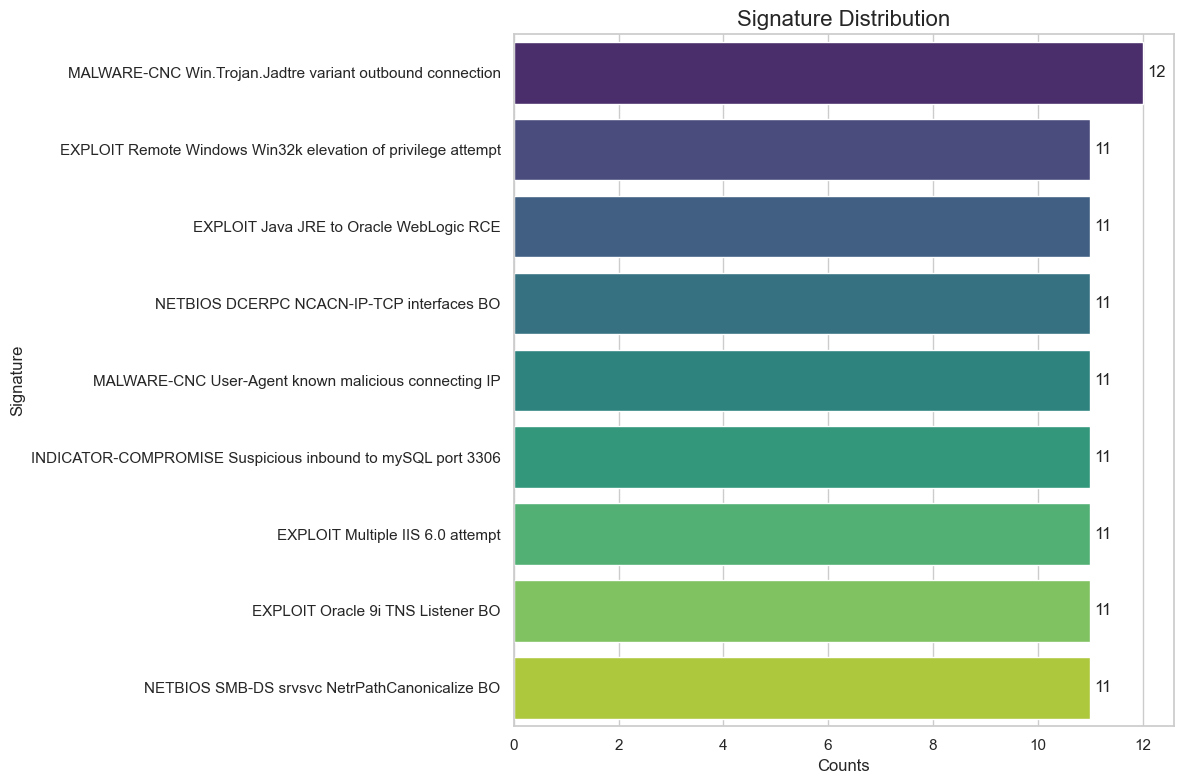

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))
    
# Построение графика
ax = sns.barplot(
    data=signature_counts,
    y='signature',
    x='count',
    hue='signature',
    palette='viridis',
    legend=False
)

# Настройка заголовков и подписей
plt.title('Signature Distribution', fontsize=16)
plt.xlabel('Counts', fontsize=12)
plt.ylabel('Signature', fontsize=12)

# Добавление значений на столбцы для наглядности
for i in ax.containers:
    ax.bar_label(i, padding=3)
    
plt.tight_layout()
plt.show()